# JOB RESUME ANALYZER PROJECT 


## INTRODUCTION
The rapid proliferation of job applications in the digital age has posed significant chal- lenges to Human Resources (HR) departments globally, particularly in the initial screening and sorting of resumes. This project addresses this scalability issue by developing a ma- chine learning-based Job Resume Analyzer and Classification System. This system automates the process of mapping unstructured resume text to predefined job categories, thereby enhancing recruitment efficiency and reducing the manual burden on recruiters.

The fundamental objective is to construct and validate a robust multi-class text classifica- tion model capable of accurately assigning a resume to one of 25 available job categories. The current manual screening process is susceptible to human bias, inconsistency, and inefficiency, especially when handling high application volumes. This automated system offers a compelling solution.

## OVERVIEW
#### •	Objectivity: Classification is based solely on the extracted technical keywords and domain-specific terminology.
#### •	Scalability: The system can process thousands of resumes near-instantly, facilitat- ing rapid decision-making.
#### •	Focus: Allows HR professionals to dedicate their time to qualitative assessment (interviews) rather than preliminary filtering.


## IMPORTING LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## UNDERSTANDING DATA

In [2]:
df = pd.read_csv("resume_data.csv")
df.head(10)

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad..."
5,Data Science,"SKILLS C Basics, IOT, Python, MATLAB, Data Sci..."
6,Data Science,Skills â¢ Python â¢ Tableau â¢ Data Visuali...
7,Data Science,Education Details \n B.Tech Rayat and Bahra ...
8,Data Science,Personal Skills â¢ Ability to quickly grasp t...
9,Data Science,Expertise â Data and Quantitative Analysis â...


In [3]:
df.tail(6)

,Category,Resume
956,Testing,COMPUTER PROFICIENCY â¢ Basic: MS-Office (Pow...
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...
961,Testing,Skill Set OS Windows XP/7/8/8.1/10 Database MY...


In [4]:
df.describe() 

,Category,Resume
count,962,962
unique,25,166
top,Java Developer,"Technical Skills Web Technologies: Angular JS,..."
freq,84,18


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


In [6]:
df.columns

Index(['Category', 'Resume'], dtype='object')

In [7]:
df.shape

(962, 2)

In [8]:
#exploring categories along with the value count for each category
print(df['Category'].value_counts())
print(df['Category'].unique())

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP

## VISUALIZING CATEGORY COUNTS AND SHARE

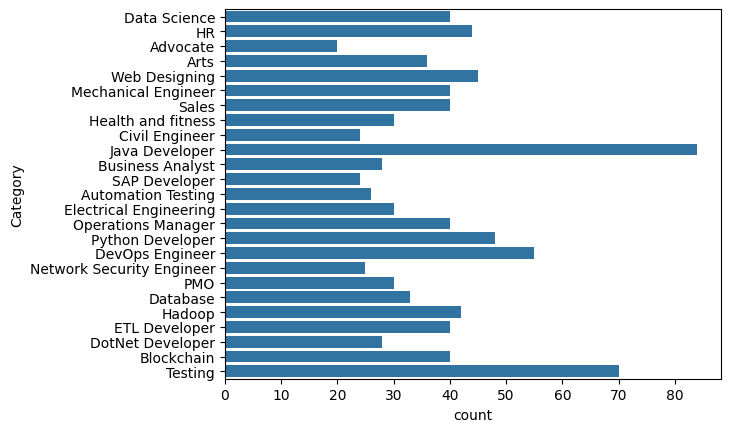

In [9]:
#visualizing category counts
sns.countplot(df['Category'])
plt.show()

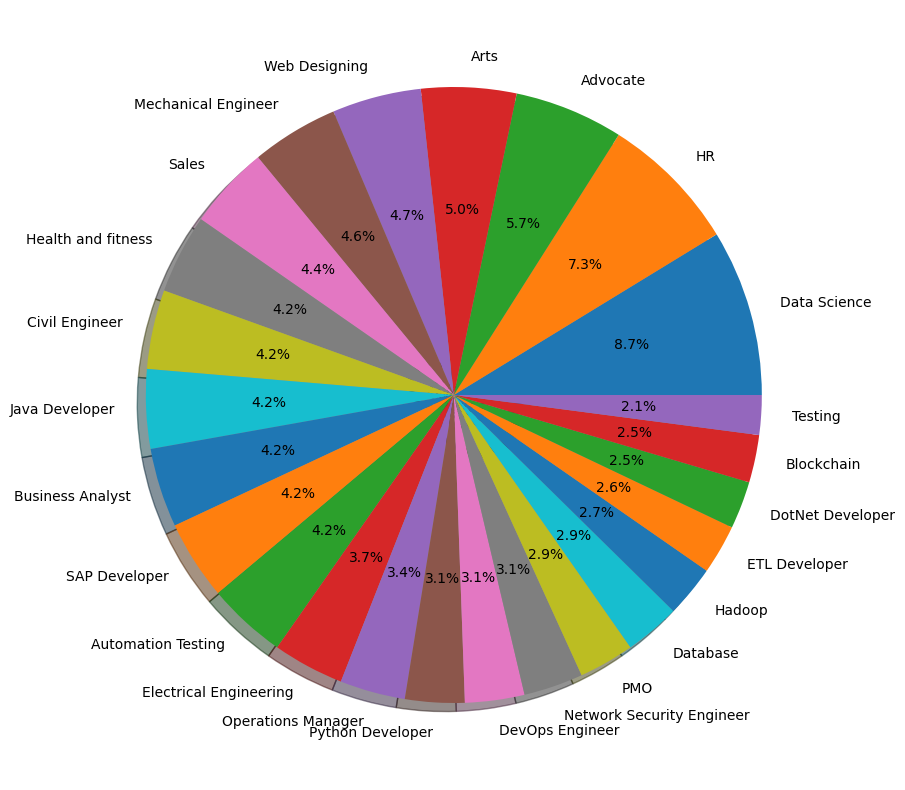

In [10]:
#category count share in form of pie chart
counts=df['Category'].value_counts()
labels=df['Category'].unique()
plt.figure(figsize=(20,10))
plt.pie(counts, labels=labels, autopct='%1.1f%%', shadow=True)
plt.show()

## EXPLORING THE DATASET

In [11]:
#display the category of resume
df['Category'][0]

'Data Science'

In [12]:
#display the whole resume
df['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \n\nData Science Assurance Associate \n\nData Science Assurance Associate - Ernst & Young LLP\nSkill Details \nJAVASCRIPT- Exprience - 24 months\njQuery- Exprience - 24 months\nPython- Exprience - 24 monthsCompany Details \ncompany - Ernst & Young LLP\ndescription - Fraud Investigations and Dispute Servi

## Cleaning the data:
1. URLs
2. hashtags
3. mentions
4. special letters
5. punctuations

### NOTE:
Cleaning of data in Python could be done using NLP (Natural Language Processing) but here we are using 're' library i.e. regular expressions library which deals with regular expressions which are powerful tools for pattern matching and manipulation of strings. It is a standard module in Python and does not require seperate installation. 

In [13]:
"""EXAMPLE AND EXPLANATION OF CLEANING PROCEDURE CODE BLOCK


import re
def cleanResume(txt):
    cleanTxt=re.sub('http\S+\s','- ',txt) # this helps in removing the attached text with the link, i.e. removes anything with the link however long will be the link.
# the link is replaced by the string i.e space in this case.
# the \S - removes the touch text attached to the link i.e. http and \s - is for // to be removed.
    
    cleanTxt=re.sub('@\S+','__',cleanTxt) #cleanTxt instead of txt cuz now the function has already been called once.
    cleanTxt=re.sub('#\S+','__',cleanTxt)

"""    


#    cleanText=re.sub('[%s]' %re.escape("""!"#$%&*+,-./:;<=>?@[\]^-`{|}~"""),' ',cleanTxt)
    #this is for removing any special characters present in the resume.

#    cleanTxt=re.sub(r'[^\x00-\x/f]',' ',cleanTxt) # negation used for removing different patterns as seen through exploration.
#    cleanTxt=re.sub('\S+',' ',cleanTxt) # this is to remove any escape sequences i.e. anything with /
#    return cleanTxt



<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Dell\AppData\Local\Temp\ipykernel_9092\2175853160.py:6: SyntaxWarning: invalid escape sequence '\S'
  cleanTxt=re.sub('http\S+\s','- ',txt) # this helps in removing the attached text with the link, i.e. removes anything with the link however long will be the link.


"EXAMPLE AND EXPLANATION OF CLEANING PROCEDURE CODE BLOCK\n\n\nimport re\ndef cleanResume(txt):\n    cleanTxt=re.sub('http\\S+\\s','- ',txt) # this helps in removing the attached text with the link, i.e. removes anything with the link however long will be the link.\n# the link is replaced by the string i.e space in this case.\n# the \\S - removes the touch text attached to the link i.e. http and \\s - is for // to be removed.\n\n    cleanTxt=re.sub('@\\S+','__',cleanTxt) #cleanTxt instead of txt cuz now the function has already been called once.\n    cleanTxt=re.sub('#\\S+','__',cleanTxt)\n\n"

In [14]:
#  cleanResume("my website goes like http://helloworld and access it @gmail.com for #checking the removal of text.")

In [15]:
# you can even remove the stoppers like and , so, or because for making vectors you will only need the big big keywords like programming, python, etc.
import re

def cleanResume(txt):
    cleanText=re.sub('http\S+\s',' ',txt)
    cleanText=re.sub('RT|CC',' ',cleanText)
    cleanText=re.sub('#\S+\s',' ',cleanText)
    cleanText=re.sub('@\S+',' ',cleanText) 
    cleanText=re.sub('[%s]' %re.escape("""!"#$%&*+,-./:;<=>?@[\]^-`{|}~"""),' ',cleanText)
    cleanText=re.sub(r"[^\x00-\x7f]",' ',cleanText)
    cleanText=re.sub('\\s+',' ',cleanText)
    return cleanText


<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\]'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\]'
C:\Users\Dell\AppData\Local\Temp\ipykernel_9092\1153416112.py:5: SyntaxWarning: invalid escape sequence '\S'
  cleanText=re.sub('http\S+\s',' ',txt)
C:\Users\Dell\AppData\Local\Temp\ipykernel_9092\1153416112.py:7: SyntaxWarning: invalid escape sequence '\S'
  cleanText=re.sub('#\S+\s',' ',cleanText)
C:\Users\Dell\AppData\Local\Temp\ipykernel_9092\1153416112.py:8: SyntaxWarning: invalid escape sequence '\S'
  cleanText=re.sub('@\S+',' ',cleanText)
C:\Users\Dell\AppData\Local\Temp\ipykernel_9092\1153416112.py:9: SyntaxWarning: invalid escape sequence '\]'
  cleanText=re.sub('[%s]' %re.escape("""

In [16]:
#now we are passing the resume for removing the elements we want or cleaning the content data of resume.
# we use lambda function as we don't have single data row but there are multiple rws i.e 962 rows 0 to 961.
# we are storing the returened clean text in the respective resume variable only.
# x is each particular resume row wise.


df['Resume']=df['Resume'].apply(lambda x: cleanResume(x))

In [17]:
# now the resume is cleaned , now checking the first row and comparing with the previously viewed version of the same in above code.

df['Resume'][0]

'Skills Programming Languages Python (pandas numpy scipy scikit learn matplotlib) Sql Java JavaScript JQuery Machine learning Regression SVM Na ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling (LDA NMF) PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3 js DC js Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learning Education Details Data Science Assurance Associate Data Science Assurance Associate Ernst Young LLP Skill Details JAVASCRIPT Exprience 24 months jQuery Exprience 24 months Python Exprience 24 monthsCompany Details company Ernst Young LLP description Fraud Investigations and Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR (Technology Assisted Review) assists in accelerati

## WORDS INTO CATEGORICAL VALUES - TRANSFORMING DATA

So, when we check the data we ask a question that if the data is supervized or unsupervized kind of problem AND this is a unsupervised type of problem, as it has one input feature and one output column.

The data can not be understood by the computer program as it is due to it being categorical, hence, we need to convert the categories into numeric values. 
This is called ENCODING or LABEL ENCODING.

In [18]:
!pip install scikit-learn

In [19]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

In [20]:
le.fit(df['Category']) 
df['Category']=le.transform(df['Category']) # we use transform function to convert the string literals into numerals. We can make a new column but it is preferable to store the transformed values in the original column by replacing the original values because it makes website making procedure easier. 

In [21]:
print(df['Category']) # or accessible through df.Category

0       6
1       6
2       6
3       6
4       6
       ..
957    23
958    23
959    23
960    23
961    23
Name: Category, Length: 962, dtype: int64


In [22]:
df.Category.unique() 

# earlier the output of this statement was :      ( but now it is different i.e. in numeric values format)


# """ ['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
#  'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
#  'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
#  'Electrical Engineering' 'Operations Manager' 'Python Developer'
#  'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
#  'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing'] """

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [23]:
# 6: 'Data Science' ,
# 12: 'HR' , 
# 0: 'Advocate', 
# 1: 'Arts' , 
# 24:'Web Designing' ,
# 16: 'Mechanical Engineer' ,
# 22: 'Sales' , 
# 14: 'Health and fitness' ,
# 5: 'Civil Engineer' , 
# 15: 'Java Developer' , 
# 4: 'Business Analyst' ,
# 21: 'SAP Developer' , 
# 2: 'Automation Testing' ,
# 11: 'Electrical Engineering'  ,
# 18: 'Operations Manager' , 
# 20: 'Python Developer' , 
# 8: 'DevOps Engineer' ,
# 17: 'Network Security Engineer' ,
# 19: 'PMO',
# 7: 'Database' ,
# 13: 'Hadoop' ,
# 10: 'ETL Developer' ,
# 9: 'DotNet Developer' ,
# 3: 'Blockchain' ,
# 23: 'Testing' 

## VECTORIZATION
The Resume is in the text format and a machine can never understand that text hence, we make vectors of that text and these depict the numeric format data of the same text alternatives.
 tfidf : Term Frequency- Inverse Document Frequency Vectorization
We make an object and then vectorize the text using vectorizer , we can even vactorize the stop_words like in  english.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words = 'english')

tfidf.fit(df['Resume'])
# df['Resume'] =tfidf.transform(df['Resume']) # this will give an error as storing in a new variable is required at this step after all you have to test split at the end.
requiredText =tfidf.transform(df['Resume'])

In [25]:
df

,Category,Resume
0,6,Skills Programming Languages Python (pandas nu...
1,6,Education Details May 2013 to May 2017 B E UIT...
2,6,Areas of Interest Deep Learning Control System...
3,6,Skills R Python SAP HANA Tableau SAP HANA SQL ...
4,6,Education Details MCA YMCAUST Faridabad Haryan...
...,...,...
957,23,Computer Skills Proficient in MS office (Word ...
958,23,Willingness to accept the challenges Positive...
959,23,PERSONAL SKILLS Quick learner Eagerness to lea...
960,23,COMPUTER SKILLS SOFTWARE KNOWLEDGE MS Power Po...


In [26]:
requiredText   # available in the form of sparse matrix i.e each row is spplitted or transformed into different different 2-d matrices with each word numbered as 0 and 1 in the respective matrice. The words found in the matrix of other rows are then numbered as 2, 3, 4, etc.  and so on

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 164050 stored elements and shape (962, 7341)>

##  DATA SPILITTING

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
# it is done as
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state =42)
# here x is the input variable and y is the category i.e output feature, and the 0.2 represents the 20% as the training will be done on 80% data and the testing will be done on 20% data.

x_train, x_test, y_train, y_test = train_test_split(requiredText, df['Category'], test_size=0.2, random_state =42)

In [29]:
x_train.shape

(769, 7341)

In [30]:
x_test.shape # the total columns are increased from the original value because of the sparse matrix made due to tfidf vectorization.

(193, 7341)

## MODEL TRAINING AND PRINTING THE CLASSIFICATION REPORT

So, this is a classification problem and we generally have two classifications i.e. 0 and 1 , but this is a multi classification problem so we will use an algorithm and here we use k- neighbours classifier which classifies the nearest bond

In [31]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
clf.fit(x_train, y_train)
ypred= clf.predict(x_test)
print(ypred)

[15 15 15 13 14 17 16  2  0 14 13 12 16 23 20  5  6  4 10  9 19  1 10 23
 23 21 22 22  2 12 18  1  8 24 11 23  7 12 24  8 18  6  8 19 24 23 21  1
 15  4 15 22 11  5 15 13  1 19  5 12 22 22 20 24 21 18 12 10 10 20 10  8
  9 21 17 21  0 17 16 14 15 11 11  8 20  3 19  8  0  2  9 10  2 23 20 20
 23 12 18 12  7 16  8 14 18  3 14 19 14 14 15 18  8  2 21 18 23 10 23  5
 11 15 12  3  5  3  7 12 19  8 20 19  3 15  9 19  1 23 21  5 20 15 16  7
  7  8 15 18  1 15 13 20  7  4 18 11  5 15  5 12  9 22 18 21  8 23  4 12
 24 16 15 22  8 22  3 16 23 23 12  7 16 18  5  3 18  8 23 23 20 21  6  7
 23]


In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(KNeighborsClassifier()) # now the KNeighborsClassifier algorithm will work for multi levels/labels.
clf.fit(x_train, y_train)
ypred= clf.predict(x_test)
print(ypred)

[15 15 15 13 14 17 16  2  0 14 13 12 16 23 20  5  6  4 10  9 19  1 10 23
 23 21 22 22  2 12 18  1  8 24 11 23  7 12 24  8 18  6  8 19 24 23 21  1
 15  4 15 22 11  5 15 13  1 19  5 12 22 22 20 24 21 18 12 10 10 20 10  8
  9 21 17 21  0 17 16 14 15 11 11  8 20  3 19  8  0  2  9 10  2 23 20 20
 23 12 18 12  7 16  8 14 18  3 14 19 14 14 15 18  8  2 21 18 23 10 23  5
 11 15 12  3  5  3  7 12 19  8 20 19  3 15  9 19  1 23 21  5 20 15 16  7
  7  8 15 18  1 15 13 20  7  4 18 11  5 15  5 12  9 22 18 21  8 23  4 12
 24 16 15 22  8 22  3 16 23 23 12  7 16 18  5  3 18  8 23 23 20 21  6  7
 23]


In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score # for improvement in accuracy

clf = OneVsRestClassifier(KNeighborsClassifier()) 
clf.fit(x_train, y_train)
ypred= clf.predict(x_test)
print(ypred)

[15 15 15 13 14 17 16  2  0 14 13 12 16 23 20  5  6  4 10  9 19  1 10 23
 23 21 22 22  2 12 18  1  8 24 11 23  7 12 24  8 18  6  8 19 24 23 21  1
 15  4 15 22 11  5 15 13  1 19  5 12 22 22 20 24 21 18 12 10 10 20 10  8
  9 21 17 21  0 17 16 14 15 11 11  8 20  3 19  8  0  2  9 10  2 23 20 20
 23 12 18 12  7 16  8 14 18  3 14 19 14 14 15 18  8  2 21 18 23 10 23  5
 11 15 12  3  5  3  7 12 19  8 20 19  3 15  9 19  1 23 21  5 20 15 16  7
  7  8 15 18  1 15 13 20  7  4 18 11  5 15  5 12  9 22 18 21  8 23  4 12
 24 16 15 22  8 22  3 16 23 23 12  7 16 18  5  3 18  8 23 23 20 21  6  7
 23]


In [34]:
# now checking accuracy score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score 

clf = OneVsRestClassifier(KNeighborsClassifier()) 
clf.fit(x_train, y_train)
ypred= clf.predict(x_test)
print(accuracy_score(y_test, ypred))

0.9844559585492227


## PREDICTION SYSTEM AND FILE DUMPING FOR DEPLOYMENT

In [35]:
import pickle 
pickle.dump(tfidf, open('tfidf.pkl', 'wb'))
pickle.dump(clf , open('clf.pkl' ,'wb'))

In [36]:
myresume = """ Here is a complete, realistic sample resume including a name and all key sections, presented in “cleaned” machine learning–ready text format. There are no special characters, no section headers, and all content is normalized for best ML/NLP compatibility. Personal and contact details appear at the start.[5][11][12][13]

***

John Anderson

Experienced data scientist and machine learning engineer with five years of experience building scalable machine learning solutions in finance and retail industries Expert in Python SQL and TensorFlow Proven ability to lead projects from idea to deployment resulting in measurable business improvements Collaborative team player with strong problem solving and communication skills

Bachelor of Technology in Computer Science ABC University Graduated May twenty twenty one

Technical skills Python SQL TensorFlow Scikit learn Pandas NumPy Java Git Machine Learning Deep Learning Data Visualization Spark Hadoop

Professional experience

Machine Learning Engineer Data Insights Inc June twenty twenty one to present Led development and deployment of fraud detection models that decreased false positives by twenty percent Managed a team of four engineers to build end to end recommendation systems using collaborative filtering and neural networks Automated model retraining and monitoring workflows improving efficiency by thirty percent Optimized data pipelines using Spark reducing processing time by forty percent Collaborated with business analysts and product managers to align technical solutions with requirements

Data Science Intern Fintech Innovations January twenty twenty one to May twenty twenty one Developed credit scoring models using logistic regression and ensemble methods Contributed to customer segmentation project using clustering algorithms Resulted in a ten percent increase in campaign effectiveness

Projects

Churn prediction system for telecom Used random forest and logistic regression to predict and reduce customer churn by fifteen percent Built sales forecasting tool for retail business with time series analysis tools on Python Developed web application to visualize and explore large datasets in real time

Certifications

TensorFlow Developer Certificate Completed September twenty twenty two Coursera Deep Learning Specialization Completed December twenty twenty two

Extracurricular activities

Mentor for data science bootcamp Guided junior participants through real world ML projects Volunteer for local education NGO Built tool to analyze student learning metrics

Personal attributes Strong analytical skills Leadership Attention to detail Adaptability Fast learner

"""



In [37]:
import pickle

# load the trained classifier
clf = pickle.load(open('clf.pkl','rb'))

# clean the input resume
cleaned_resume = cleanResume(myresume)

# transform the cleaned resume using the TfidfVectorizer
input_features = tfidf.transform([cleaned_resume])

# make the prediction using the loaded classifier
prediction_id = clf.predict(input_features)[0]

# map category ID to category name
category_mapping = { 
6: 'Data Science' ,
12: 'HR' , 
0: 'Advocate', 
1: 'Arts' , 
24:'Web Designing' ,
16: 'Mechanical Engineer' ,
22: 'Sales' , 
14: 'Health and fitness' ,
5: 'Civil Engineer' , 
15: 'Java Developer' , 
4: 'Business Analyst' ,
21: 'SAP Developer' , 
2: 'Automation Testing' ,
11: 'Electrical Engineering'  ,
18: 'Operations Manager' , 
20: 'Python Developer' , 
8: 'DevOps Engineer' ,
17: 'Network Security Engineer' ,
19: 'PMO',
7: 'Database' ,
13: 'Hadoop' ,
10: 'ETL Developer' ,
9: 'DotNet Developer' ,
3: 'Blockchain' ,
23: 'Testing' 
}

category_name = category_mapping.get(prediction_id, "Unknown")

print("Predicted Category : ", category_name)

#print(prediction_id)

#print( "Category is : " , """ ' """,prediction_id,""" ' """ , ":" , """ ' """ , category_name , """ ' """)














Predicted Category :  Data Science


In [38]:
import pickle

# save trained model
with open("knn_model.pkl", "wb") as f:
    pickle.dump(clf, f)  # or use your model variable name (e.g. 'model' instead of 'knn')

# save vectorizer (TF-IDF or CountVectorizer)
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)  # replace 'tfidf' with your vectorizer variable

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

## ACCURACY SCORE

In [39]:
# Lastly, showing the accuracy score of the predictions of model.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score 

clf = OneVsRestClassifier(KNeighborsClassifier()) 
clf.fit(x_train, y_train)
ypred= clf.predict(x_test)
print(accuracy_score(y_test, ypred))

0.9844559585492227


## CONCLUSION 
#### The successful implementation of the Job Resume Analyzer and Classification System, achieving an accuracy of approximately 98%, validates the power of integrating classical NLP techniques with supervised machine learning. The solution provides a valuable, high- accuracy tool for modern talent acquisition, promising substantial gains in operational efficiency and objective screening.

## FUTURE SCOPE
##### While the current model performs excellently, several avenues exist to enhance its robust- ness and utility:
•	Hyperparameter Optimization: Employ advanced tuning methods (e.g., Grid Search) to find the optimal K value for the KNN classifier.
•	Deep Learning Integration: Explore state-of-the-art deep learning models, specif- ically pre-trained Transformer models (e.g., BERT), which capture contextual and semantic meaning, enhancing generalization.
•	Addressing Imbalance: Implement synthetic data generation techniques like SMOTE on the minority classes to ensure equal robustness across all 25 categories.
•	Productionalization: Develop a user-facing web application interface (using tech- nologies like Python Flask/Django) for real-time predictions.
